In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
from probcs.utils.utils import load_images
from torchvision import transforms
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior_binary
import pickle
import pandas as pd
import os
import glob

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [4]:
results_dict = {
    'stimulus_id': [],
    'big_stimulus': [],
    'small_x_mean': [],
    'small_g_mean': [],
    'big_x_mean': [],
    'big_g_mean': [],
}

# Find all small stimulus .pkl files in the results directory
small_pkl_files = glob.glob("gratings_results/coen_cagli_small_gratings_*.pkl")
print(f"Found {len(small_pkl_files)} small stimulus .pkl files:")
for file in small_pkl_files:
    print(f"  {file}")

# Process each small stimulus .pkl file
for results_path in small_pkl_files:
    # Load the small stimulus pickle file
    with open(results_path, "rb") as f:
        results = pickle.load(f)
        X = results['posterior']['X'].data
        X_mean = X.mean((0, 1))
        G = results['posterior']['G'].data
        G_mean = G.mean((0, 1))
        
        # Extract ID from filename
        stimulus_id = int(results_path.split("_")[-1].strip(".pkl"))
        
        # Load corresponding small stimulus image file
        image_path = results_path.replace("small_gratings_results", "presented_big_gratings").replace(".pkl", ".npy")
        with open(image_path, "rb") as image_f:
            image = np.load(image_f)
        
        # Load corresponding big stimulus results
        big_results_path = f"gratings_results/coen_cagli_big_gratings_results_{stimulus_id}.pkl"
        with open(big_results_path, "rb") as big_f:
            big_results = pickle.load(big_f)
            big_X = big_results['posterior']['X'].data
            big_x_mean = big_X.mean((0, 1))
            big_G = big_results['posterior']['G'].data
            big_g_mean = big_G.mean((0, 1))
        
        # Append to results dictionary
        results_dict['stimulus_id'].append(stimulus_id)
        results_dict['big_stimulus'].append(image)
        results_dict['small_x_mean'].append(X_mean)
        results_dict['small_g_mean'].append(G_mean)
        results_dict['big_x_mean'].append(big_x_mean)
        results_dict['big_g_mean'].append(big_g_mean)
        
        print(f"Processed {results_path} with stimulus_id {stimulus_id}")

# Convert to pandas DataFrame
df = pd.DataFrame(results_dict)

# Add center mean columns
G_dim = 10
center_ids = list(range(G_dim*4, G_dim*4 + G_dim))  # [40, 41, 42, ..., 49]

print(f"Center IDs: {center_ids}")
print(f"This corresponds to indices {G_dim*4} to {G_dim*4 + G_dim - 1}")

# Extract the center region for each small_x_mean and compute its mean
df['small_x_center_mean'] = df['small_x_mean'].apply(lambda x: x[center_ids].mean())

# Extract the center region for each big_x_mean and compute its mean
df['big_x_center_mean'] = df['big_x_mean'].apply(lambda x: x[center_ids].mean())

Found 1000 small stimulus .pkl files:
  gratings_results/coen_cagli_small_gratings_results_584.pkl
  gratings_results/coen_cagli_small_gratings_results_201.pkl
  gratings_results/coen_cagli_small_gratings_results_605.pkl
  gratings_results/coen_cagli_small_gratings_results_467.pkl
  gratings_results/coen_cagli_small_gratings_results_843.pkl
  gratings_results/coen_cagli_small_gratings_results_78.pkl
  gratings_results/coen_cagli_small_gratings_results_188.pkl
  gratings_results/coen_cagli_small_gratings_results_328.pkl
  gratings_results/coen_cagli_small_gratings_results_476.pkl
  gratings_results/coen_cagli_small_gratings_results_38.pkl
  gratings_results/coen_cagli_small_gratings_results_496.pkl
  gratings_results/coen_cagli_small_gratings_results_571.pkl
  gratings_results/coen_cagli_small_gratings_results_331.pkl
  gratings_results/coen_cagli_small_gratings_results_378.pkl
  gratings_results/coen_cagli_small_gratings_results_272.pkl
  gratings_results/coen_cagli_small_gratings_resu

In [5]:
df

,stimulus_id,big_stimulus,small_x_mean,small_g_mean,big_x_mean,big_g_mean,small_x_center_mean,big_x_center_mean
0,584,"[[-9.891494860631777, -8.102307643501158, -5.9...","[0.11666666666666667, 0.09083333333333334, 0.0...","[0.08083333333333333, 0.06333333333333334, 0.0...","[0.3925, 0.12333333333333334, 0.13, 0.045, 0.0...","[0.4775, 0.135, 0.13416666666666666, 0.0008333...",0.077500,0.079250
1,201,"[[-10.622218138564058, -11.865561961387737, -1...","[0.12166666666666667, 0.04416666666666667, 0.0...","[0.09916666666666667, 0.010833333333333334, 0....","[0.31166666666666665, 0.11, 0.2158333333333333...","[0.335, 0.0925, 0.25, 0.125, 0.2225, 0.3133333...",0.115583,0.091167
2,605,"[[-7.8298618877148805, -12.181447712308406, -9...","[0.15583333333333332, 0.0975, 0.05583333333333...","[0.1375, 0.07666666666666666, 0.02666666666666...","[0.2275, 0.03833333333333333, 0.1925, 0.1525, ...","[0.21333333333333335, 0.0, 0.21583333333333332...",0.104167,0.090333
3,467,"[[-9.688390236477835, -11.625003324981423, -12...","[0.16833333333333333, 0.04416666666666667, 0.3...","[0.20083333333333334, 0.0, 0.4875, 0.149166666...","[0.13916666666666666, 0.0275, 0.1025, 0.209166...","[0.1125, 0.0, 0.06333333333333334, 0.219166666...",0.104583,0.096750
4,843,"[[12.268741133197048, 8.287346649981565, -0.60...","[0.045, 0.035, 0.0675, 0.2475, 0.0641666666666...","[0.0, 0.0, 0.021666666666666667, 0.27, 0.04083...","[0.27666666666666667, 0.105, 0.064166666666666...","[0.3075, 0.095, 0.021666666666666667, 0.000833...",0.071167,0.109000
...,...,...,...,...,...,...,...,...
995,96,"[[6.949403667063782, 2.3044359406149457, -2.72...","[0.195, 0.165, 0.04083333333333333, 0.2325, 0....","[0.20333333333333334, 0.16083333333333333, 0.0...","[0.16833333333333333, 0.17083333333333334, 0.0...","[0.16333333333333333, 0.16833333333333333, 0.0...",0.058167,0.099167
996,847,"[[-12.21385232471929, -8.670023988883317, -1.2...","[0.4625, 0.12916666666666668, 0.11916666666666...","[0.55, 0.1175, 0.1125, 0.008333333333333333, 0...","[0.18916666666666668, 0.11166666666666666, 0.2...","[0.1875, 0.09416666666666666, 0.29083333333333...",0.079750,0.085500
997,175,"[[-11.957065014356283, -11.99562192379507, -9....","[0.2608333333333333, 0.07416666666666667, 0.16...","[0.2866666666666667, 0.05416666666666667, 0.15...","[0.0975, 0.09416666666666666, 0.05916666666666...","[0.07916666666666666, 0.075, 0.0, 0.0166666666...",0.089500,0.100667
998,743,"[[-2.75442836714232, -3.2803438581497675, -3.7...","[0.42, 0.22583333333333333, 0.0575, 0.16166666...","[0.4975, 0.25083333333333335, 0.0275, 0.143333...","[0.38083333333333336, 0.1425, 0.15166666666666...","[0.42833333333333334, 0.13583333333333333, 0.1...",0.077833,0.104417


In [6]:
# Create a dictionary to store the top 200 stimulus IDs for each center neuron
top_activating_stimuli = {}

# For each center neuron
for i, center_neuron_idx in enumerate(center_ids):
    # Extract the activation values for this specific center neuron across all stimuli
    neuron_activations = df['small_x_mean'].apply(lambda x: x[center_neuron_idx])
    
    # Get the indices of the top 200 most activating stimuli
    top_200_indices = neuron_activations.nlargest(200).index
    
    # Get the corresponding stimulus IDs
    top_200_stimulus_ids = df.loc[top_200_indices, 'stimulus_id'].tolist()
    
    # Store in dictionary
    neuron_name = f'center_neuron_{i}'  # neuron 0-9
    top_activating_stimuli[neuron_name] = top_200_stimulus_ids
    
    print(f"Center neuron {i} (index {center_neuron_idx}): Top 200 stimulus IDs")
    print(f"  Max activation: {neuron_activations.max():.4f}")
    print(f"  Min activation in top 200: {neuron_activations.iloc[top_200_indices].min():.4f}")
    print(f"  Sample stimulus IDs: {top_200_stimulus_ids[:10]}")

print(f"Created dictionary with {len(top_activating_stimuli)} center neurons")
print(f"Each neuron has {len(top_activating_stimuli['center_neuron_0'])} top activating stimulus IDs")

Center neuron 0 (index 40): Top 200 stimulus IDs
  Max activation: 0.5767
  Min activation in top 200: 0.3017
  Sample stimulus IDs: [64, 473, 393, 304, 838, 332, 835, 897, 722, 242]
Center neuron 1 (index 41): Top 200 stimulus IDs
  Max activation: 0.3392
  Min activation in top 200: 0.1367
  Sample stimulus IDs: [348, 115, 789, 202, 490, 856, 11, 457, 667, 302]
Center neuron 2 (index 42): Top 200 stimulus IDs
  Max activation: 0.5308
  Min activation in top 200: 0.1242
  Sample stimulus IDs: [195, 114, 742, 289, 292, 568, 544, 24, 609, 560]
Center neuron 3 (index 43): Top 200 stimulus IDs
  Max activation: 0.2783
  Min activation in top 200: 0.0767
  Sample stimulus IDs: [267, 298, 245, 102, 610, 508, 166, 119, 458, 216]
Center neuron 4 (index 44): Top 200 stimulus IDs
  Max activation: 0.7983
  Min activation in top 200: 0.2308
  Sample stimulus IDs: [201, 69, 283, 982, 912, 950, 67, 829, 435, 313]
Center neuron 5 (index 45): Top 200 stimulus IDs
  Max activation: 0.4942
  Min activ

In [8]:
# Create a more organized DataFrame for analysis
top_stimuli_data = []

for neuron_name, stimulus_ids in top_activating_stimuli.items():
    neuron_idx = int(neuron_name.split('_')[-1])  # Extract neuron index (0-9)
    center_neuron_pos = center_ids[neuron_idx]  # Get the actual position in x_mean (40-49)
    
    for rank, stimulus_id in enumerate(stimulus_ids):
        # Get the activation value for this stimulus and neuron
        row_idx = df[df['stimulus_id'] == stimulus_id].index[0]
        
        # Current center neuron activation
        small_center_x_mean = df.loc[row_idx, 'small_x_mean'][center_neuron_pos]
        big_center_x_mean = df.loc[row_idx, 'big_x_mean'][center_neuron_pos]
        
        # Get full arrays for small and big stimulus
        small_x_full = df.loc[row_idx, 'small_x_mean']
        big_x_full = df.loc[row_idx, 'big_x_mean']
        small_g_full = df.loc[row_idx, 'small_g_mean']
        big_g_full = df.loc[row_idx, 'big_g_mean']
        
        # All center neurons (include all 10 center neurons)
        small_all_center_array = small_x_full[center_ids]
        big_all_center_array = big_x_full[center_ids]
        
        # All neurons (include all neurons, preserving order)
        small_all_other_array = small_x_full
        big_all_other_array = big_x_full
        
        # All G neurons
        small_g_array = small_g_full
        big_g_array = big_g_full
        
        top_stimuli_data.append({
            'neuron_idx': neuron_idx,
            'center_neuron_pos': center_neuron_pos,
            'stimulus_id': stimulus_id,
            'rank': rank + 1,  # 1-indexed rank
            'small_x_center': small_center_x_mean,
            'big_x_center': big_center_x_mean,
            'small_x_all_center_array': small_all_center_array,
            'big_x_all_center_array': big_all_center_array,
            'small_x_all_other_array': small_all_other_array,
            'big_x_all_other_array': big_all_other_array,
            'small_g_array': small_g_array,
            'big_g_array': big_g_array
        })

# Create DataFrame
top_stimuli_df = pd.DataFrame(top_stimuli_data)

In [9]:
top_stimuli_df

,neuron_idx,center_neuron_pos,stimulus_id,rank,small_x_center,big_x_center,small_x_all_center_array,big_x_all_center_array,small_x_all_other_array,big_x_all_other_array,small_g_array,big_g_array
0,0,40,64,1,0.576667,0.215000,"[0.5766666666666667, 0.056666666666666664, 0.0...","[0.215, 0.1575, 0.11, 0.034166666666666665, 0....","[0.6333333333333333, 0.085, 0.04, 0.0733333333...","[0.22916666666666666, 0.24666666666666667, 0.2...","[0.7791666666666667, 0.0525, 0.009166666666666...","[0.23416666666666666, 0.2808333333333333, 0.20..."
1,0,40,473,2,0.526667,0.209167,"[0.5266666666666666, 0.05, 0.1425, 0.0675, 0.1...","[0.20916666666666667, 0.16666666666666666, 0.0...","[0.5408333333333334, 0.06833333333333333, 0.21...","[0.24583333333333332, 0.25666666666666665, 0.0...","[0.655, 0.045, 0.2225, 0.1675, 0.14, 0.2525, 0...","[0.25, 0.2966666666666667, 0.02416666666666666..."
2,0,40,393,3,0.520833,0.315000,"[0.5208333333333334, 0.0175, 0.029166666666666...","[0.315, 0.019166666666666665, 0.15333333333333...","[0.64, 0.03, 0.05416666666666667, 0.0408333333...","[0.35, 0.04666666666666667, 0.2183333333333333...","[0.7741666666666667, 0.0008333333333333334, 0....","[0.415, 0.0, 0.25, 0.0725, 0.2783333333333333,..."
3,0,40,304,4,0.514167,0.233333,"[0.5141666666666667, 0.03833333333333333, 0.02...","[0.23333333333333334, 0.041666666666666664, 0....","[0.645, 0.04833333333333333, 0.048333333333333...","[0.2841666666666667, 0.08916666666666667, 0.04...","[0.7908333333333334, 0.028333333333333332, 0.0...","[0.30833333333333335, 0.05583333333333333, 0.0..."
4,0,40,838,5,0.513333,0.159167,"[0.5133333333333333, 0.03833333333333333, 0.02...","[0.15916666666666668, 0.045, 0.019166666666666...","[0.645, 0.04833333333333333, 0.048333333333333...","[0.19416666666666665, 0.09333333333333334, 0.0...","[0.7908333333333334, 0.028333333333333332, 0.0...","[0.19333333333333333, 0.06916666666666667, 0.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9,49,786,196,0.068333,0.129167,"[0.13083333333333333, 0.018333333333333333, 0....","[0.14916666666666667, 0.04666666666666667, 0.0...","[0.17583333333333334, 0.025833333333333333, 0....","[0.20416666666666666, 0.07083333333333333, 0.0...","[0.19166666666666668, 0.0, 0.1175, 0.0175, 0.0...","[0.18916666666666668, 0.051666666666666666, 0...."
1996,9,49,893,197,0.068333,0.046667,"[0.405, 0.05333333333333334, 0.0175, 0.0116666...","[0.08916666666666667, 0.021666666666666667, 0....","[0.465, 0.11916666666666667, 0.055, 0.05333333...","[0.11416666666666667, 0.06416666666666666, 0.0...","[0.5516666666666666, 0.1125, 0.0, 0.0225, 0.07...","[0.07666666666666666, 0.03916666666666667, 0.0..."
1997,9,49,682,198,0.068333,0.033333,"[0.009166666666666667, 0.0825, 0.0783333333333...","[0.025833333333333333, 0.0125, 0.0175, 0.095, ...","[0.055, 0.14666666666666667, 0.14, 0.201666666...","[0.04, 0.0475, 0.0475, 0.3258333333333333, 0.0...","[0.0, 0.1575, 0.12333333333333334, 0.216666666...","[0.0, 0.0, 0.0, 0.3875, 0.04666666666666667, 0..."
1998,9,49,710,199,0.068333,0.155000,"[0.16333333333333333, 0.1525, 0.17166666666666...","[0.06666666666666667, 0.055, 0.054166666666666...","[0.24333333333333335, 0.24416666666666667, 0.2...","[0.0825, 0.08916666666666667, 0.08083333333333...","[0.2525, 0.28833333333333333, 0.23833333333333...","[0.051666666666666666, 0.06583333333333333, 0...."


In [10]:
# Analysis: Compare small vs big stimulus center activations
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the difference between big and small center activations
top_stimuli_df['center_activation_ratio'] = top_stimuli_df['big_x_center'] / top_stimuli_df['small_x_center']
top_stimuli_df['center_activation_diff'] = top_stimuli_df['big_x_center'] - top_stimuli_df['small_x_center']

# Summary statistics
print("=== Small vs Big Stimulus Center Activation Analysis ===")
print(f"Total number of stimulus-neuron pairs: {len(top_stimuli_df)}")
print()

print("Summary Statistics:")
print(f"Small stimulus center activation - Mean: {top_stimuli_df['small_x_center'].mean():.4f}, Std: {top_stimuli_df['small_x_center'].std():.4f}")
print(f"Big stimulus center activation - Mean: {top_stimuli_df['big_x_center'].mean():.4f}, Std: {top_stimuli_df['big_x_center'].std():.4f}")
print(f"Activation ratio (big / small) - Mean: {top_stimuli_df['center_activation_ratio'].mean():.4f}, Std: {top_stimuli_df['center_activation_ratio'].std():.4f}")
print()

# Check how many cases have higher/lower activation with big stimulus
higher_with_big = (top_stimuli_df['big_x_center'] > top_stimuli_df['small_x_center']).sum()
lower_with_big = (top_stimuli_df['big_x_center'] < top_stimuli_df['small_x_center']).sum()
equal = (top_stimuli_df['big_x_center'] == top_stimuli_df['small_x_center']).sum()

print("Comparison Results:")
print(f"Cases where big stimulus has HIGHER activation: {higher_with_big} ({100*higher_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where big stimulus has LOWER activation: {lower_with_big} ({100*lower_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where activations are EQUAL: {equal} ({100*equal/len(top_stimuli_df):.1f}%)")
print()

# Analysis by neuron
print("Analysis by Center Neuron:")
neuron_analysis = top_stimuli_df.groupby('neuron_idx').agg({
    'small_x_center': ['mean', 'std'],
    'big_x_center': ['mean', 'std'],
    'center_activation_ratio': ['mean', 'std'],
    'center_activation_diff': ['mean', 'std'],
}).round(4)

print(neuron_analysis)

=== Small vs Big Stimulus Center Activation Analysis ===
Total number of stimulus-neuron pairs: 2000

Summary Statistics:
Small stimulus center activation - Mean: 0.2105, Std: 0.0989
Big stimulus center activation - Mean: 0.1213, Std: 0.1046
Activation ratio (big / small) - Mean: 0.6099, Std: 0.5081

Comparison Results:
Cases where big stimulus has HIGHER activation: 370 (18.5%)
Cases where big stimulus has LOWER activation: 1625 (81.2%)
Cases where activations are EQUAL: 5 (0.2%)

Analysis by Center Neuron:
           small_x_center         big_x_center          \
                     mean     std         mean     std   
neuron_idx                                               
0                  0.3593  0.0543       0.1844  0.1198   
1                  0.1864  0.0417       0.0866  0.0694   
2                  0.1880  0.0620       0.1055  0.0854   
3                  0.1190  0.0405       0.0606  0.0555   
4                  0.3276  0.0873       0.1934  0.1319   
5                  0.2

In [12]:
# Calculate Modulation Ratio (MR) and Geometric Mean
# MR = big_response / small_response (same as center_activation_ratio)
# MR < 1: surround suppression
# MR > 1: facilitation

# Filter for images that evoked a measurable response (non-zero small stimulus activation)
measurable_responses = top_stimuli_df[top_stimuli_df['small_x_center'] > 0].copy()

print("=== Modulation Ratio (MR) Analysis ===")
print(f"Total stimulus-neuron pairs: {len(top_stimuli_df)}")
print(f"Pairs with measurable response (small_x_center > 0): {len(measurable_responses)}")
print(f"Percentage with measurable response: {100 * len(measurable_responses) / len(top_stimuli_df):.1f}%")
print()

if len(measurable_responses) > 0:
    # Calculate geometric mean of MR
    from scipy import stats
    
    # Geometric mean using scipy
    geometric_mean_mr = stats.gmean(measurable_responses['center_activation_ratio'])
    
    # Alternative calculation: exp(mean(log(MR)))
    geometric_mean_mr_alt = np.exp(np.log(measurable_responses['center_activation_ratio']).mean())
    
    print("Modulation Ratio (MR) Statistics:")
    print(f"Arithmetic mean MR: {measurable_responses['center_activation_ratio'].mean():.4f}")
    print(f"Geometric mean MR: {geometric_mean_mr:.4f}")
    print(f"Geometric mean MR (alternative calc): {geometric_mean_mr_alt:.4f}")
    print(f"Median MR: {measurable_responses['center_activation_ratio'].median():.4f}")
    print()
    
    # Classification of responses
    suppression = (measurable_responses['center_activation_ratio'] < 1).sum()
    facilitation = (measurable_responses['center_activation_ratio'] > 1).sum()
    no_change = (measurable_responses['center_activation_ratio'] == 1).sum()
    
    print("Response Classification:")
    print(f"Surround suppression (MR < 1): {suppression} ({100*suppression/len(measurable_responses):.1f}%)")
    print(f"Facilitation (MR > 1): {facilitation} ({100*facilitation/len(measurable_responses):.1f}%)")
    print(f"No change (MR = 1): {no_change} ({100*no_change/len(measurable_responses):.1f}%)")
    print()
    
    print(f"*** The geometric mean of the MR for gratings that evoked a measurable response was {geometric_mean_mr:.4f} ***")
    
    if geometric_mean_mr < 1:
        print("This indicates overall SURROUND SUPPRESSION when enlarging stimuli.")
    elif geometric_mean_mr > 1:
        print("This indicates overall FACILITATION when enlarging stimuli.")
    else:
        print("This indicates NO NET EFFECT when enlarging stimuli.")
        
else:
    print("No measurable responses found!")

=== Modulation Ratio (MR) Analysis ===
Total stimulus-neuron pairs: 2000
Pairs with measurable response (small_x_center > 0): 2000
Percentage with measurable response: 100.0%

Modulation Ratio (MR) Statistics:
Arithmetic mean MR: 0.6099
Geometric mean MR: 0.4125
Geometric mean MR (alternative calc): 0.4125
Median MR: 0.4754

Response Classification:
Surround suppression (MR < 1): 1625 (81.2%)
Facilitation (MR > 1): 370 (18.5%)
No change (MR = 1): 5 (0.2%)

*** The geometric mean of the MR for gratings that evoked a measurable response was 0.4125 ***
This indicates overall SURROUND SUPPRESSION when enlarging stimuli.


/tmp/ipykernel_3848346/4128131228.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  axes[0, 0].plot([0, top_stimuli_df['small_x_center'].max()],


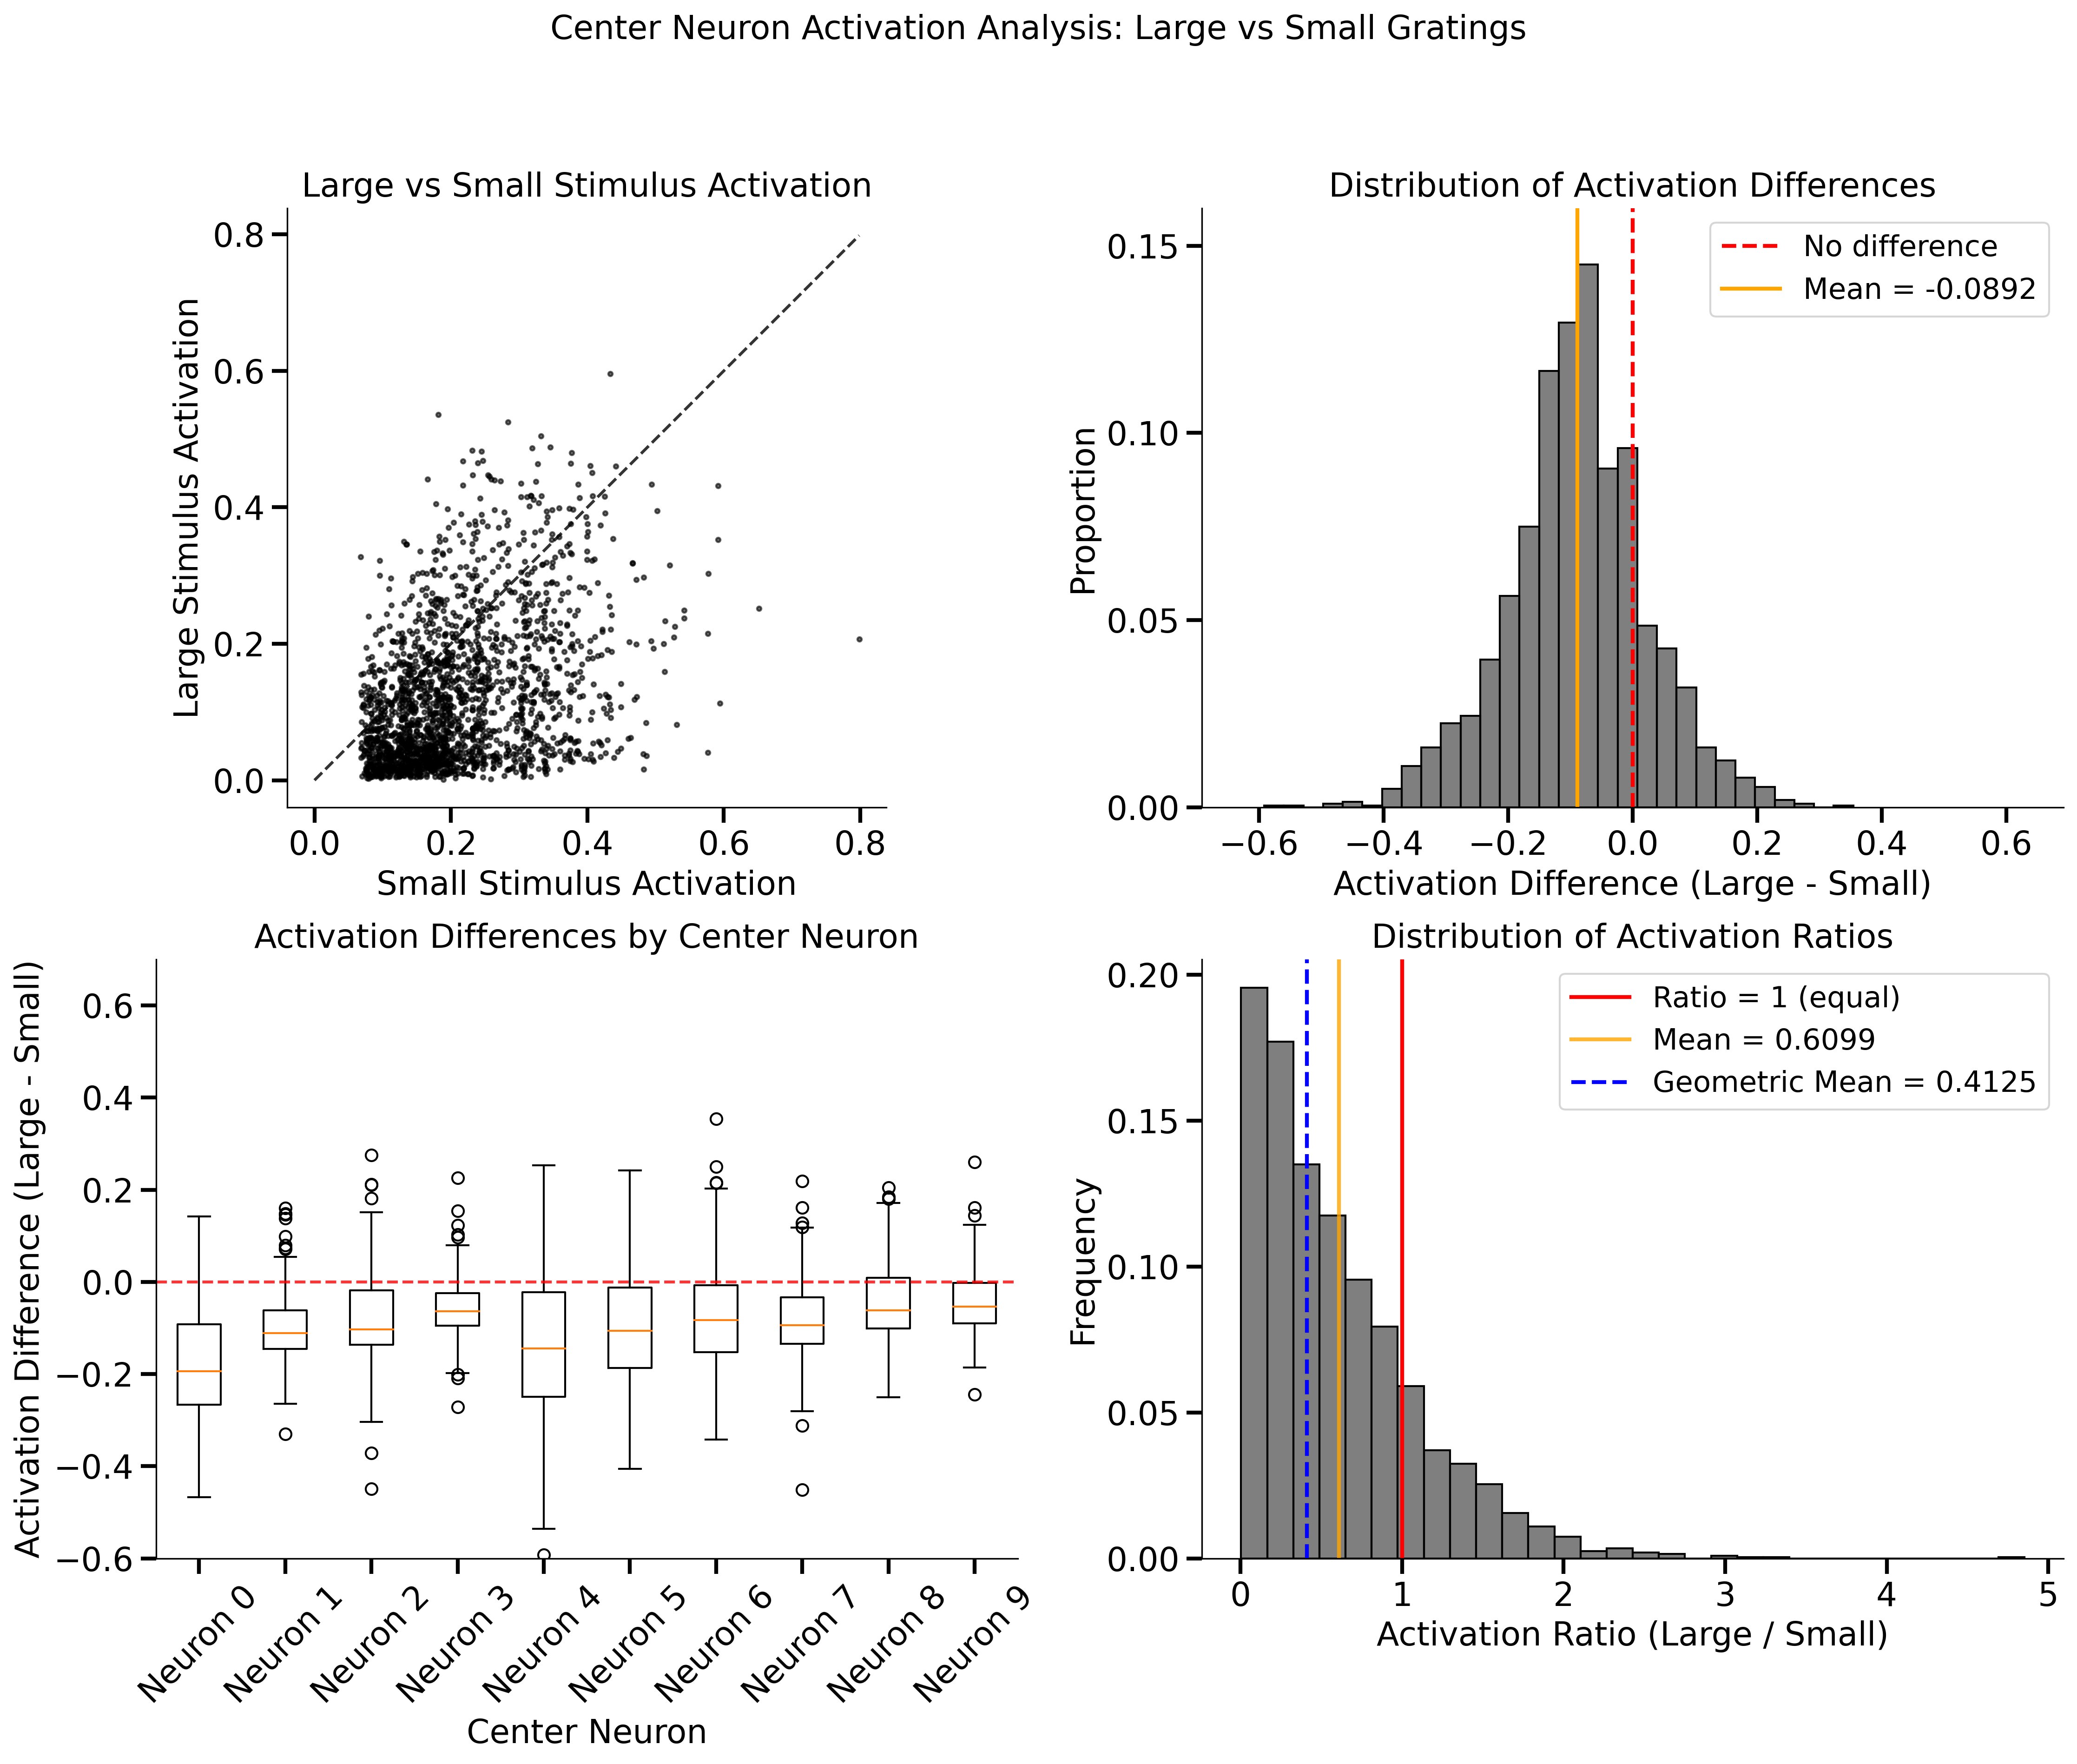

In [14]:
scatter_alpha = 0.6
yx_alpha = 0.8
yx_color = "black"
grid_alpha = 0.3
scatter_size = 5
scatter_color = "black"
xlabel_size = 17
ylabel_size = 17
title_size = 17
tick_label_size = 17
tick_length = 8
tick_width = 2

bins = 30
bar_alpha = 0.5
bar_color = 'black'
edge_color = 'black'
no_diffline_color = 'red'
no_diffline_width = 2

mean_line_color = 'orange'
mean_line_width = 2

legend_size = 15


# Visualizations: Small vs Big Stimulus Center Activations
fig, axes = plt.subplots(2, 2, figsize=(15, 12), dpi=300)


# 1. Scatter plot: Small vs Big activation
axes[0, 0].scatter(top_stimuli_df['small_x_center'], top_stimuli_df['big_x_center'], 
                   alpha=scatter_alpha, s=scatter_size, color=scatter_color)
axes[0, 0].plot([0, top_stimuli_df['small_x_center'].max()], 
                [0, top_stimuli_df['small_x_center'].max()], 'r--', alpha=yx_alpha, color=yx_color)
axes[0, 0].set_xticks(np.arange(0, top_stimuli_df['small_x_center'].max() + 0.1, 0.2))
axes[0, 0].set_yticks(np.arange(0, top_stimuli_df['small_x_center'].max() + 0.1, 0.2))
axes[0, 0].set_xlabel('Small Stimulus Activation', fontsize=xlabel_size)
axes[0, 0].set_ylabel('Large Stimulus Activation', fontsize=ylabel_size)
axes[0, 0].set_title('Large vs Small Stimulus Activation', fontsize=title_size)
axes[0, 0].set_aspect('equal', adjustable='box')

# 2. Distribution of activation differences
sns.histplot(top_stimuli_df['center_activation_diff'], bins=bins, alpha=bar_alpha, edgecolor=edge_color, color=bar_color, 
             ax=axes[0, 1], stat='proportion')
# axes[0, 1].hist(top_stimuli_df['center_activation_diff'], bins=bins, alpha=bar_alpha, edgecolor=edge_color, color=bar_color, density=True)
axes[0, 1].axvline(0, color=no_diffline_color, linewidth=no_diffline_width, linestyle='--', label='No difference')
axes[0, 1].axvline(top_stimuli_df['center_activation_diff'].mean(), color=mean_line_color, linewidth=mean_line_width,
                   linestyle='-', label=f'Mean = {top_stimuli_df["center_activation_diff"].mean():.4f}')
axes[0, 1].set_xlim(top_stimuli_df['center_activation_diff'].min() - 0.1, 
                    abs(top_stimuli_df['center_activation_diff'].min()) + 0.1)
axes[0, 1].set_xlabel('Activation Difference (Large - Small)', fontsize=xlabel_size)
axes[0, 1].set_ylabel('Proportion', fontsize=ylabel_size)
axes[0, 1].set_title('Distribution of Activation Differences', fontsize=title_size)
axes[0, 1].set_yticks(np.arange(0, 0.16, 0.05))
axes[0, 1].set_ylim(0, 0.16)
axes[0, 1].legend(prop={'size': legend_size})

# 3. Box plot by neuron
neuron_data = []
neuron_labels = []
for neuron_idx in sorted(top_stimuli_df['neuron_idx'].unique()):
    neuron_subset = top_stimuli_df[top_stimuli_df['neuron_idx'] == neuron_idx]
    neuron_data.append(neuron_subset['center_activation_diff'])
    neuron_labels.append(f'Neuron {neuron_idx}')

axes[1, 0].boxplot(neuron_data, labels=neuron_labels)
axes[1, 0].set_xlabel('Center Neuron', fontsize=xlabel_size)
axes[1, 0].set_ylabel('Activation Difference (Large - Small)', fontsize=ylabel_size)
axes[1, 0].set_title('Activation Differences by Center Neuron', fontsize=title_size)
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=tick_label_size)
axes[1, 0].set_ylim((-0.6, 0.7))
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.8)

# 4. Activation ratio distribution
sns.histplot(top_stimuli_df['center_activation_ratio'], bins=bins, alpha=bar_alpha, edgecolor=edge_color, color=bar_color, 
             ax=axes[1, 1], stat='proportion')
axes[1, 1].axvline(1, linestyle='-', color=no_diffline_color, label='Ratio = 1 (equal)', linewidth=no_diffline_width)
axes[1, 1].axvline(top_stimuli_df['center_activation_ratio'].mean(), color=mean_line_color, linewidth=mean_line_width,
                   linestyle='-', alpha=0.8, label=f'Mean = {top_stimuli_df["center_activation_ratio"].mean():.4f}')
axes[1, 1].axvline(geometric_mean_mr, color='blue', linewidth=mean_line_width,
                   linestyle='--', label=f'Geometric Mean = {geometric_mean_mr:.4f}')
axes[1, 1].set_xlabel('Activation Ratio (Large / Small)', fontsize=xlabel_size)
axes[1, 1].set_ylabel('Frequency', fontsize=ylabel_size)
axes[1, 1].set_title('Distribution of Activation Ratios', fontsize=title_size)
axes[1, 1].legend(prop={'size': legend_size})
axes[1, 1].set_yticks(np.arange(0, 0.21, 0.05))

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='minor', labelsize=tick_label_size)
    # ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', which='both', length=tick_length, width=tick_width)
    sns.despine(ax=ax)
fig.suptitle('Center Neuron Activation Analysis: Large vs Small Gratings', fontsize=title_size, y=1.05)
plt.tight_layout()
plt.show()
fig.savefig('large_vs_small_gratings_center_neuron.pdf', dpi=300, bbox_inches='tight')

In [15]:
# Analysis: G neuron responses to small vs big stimuli
# Understanding if inhibitory G neurons drive the center X neuron effects

print("=== G Neuron (Inhibitory) Response Analysis ===")
print(f"Total stimulus-neuron pairs: {len(top_stimuli_df)}")
print()

# Add G neuron mean activations to our analysis DataFrame
top_stimuli_df['small_g_mean'] = top_stimuli_df['small_g_array'].apply(lambda x: x.mean())
top_stimuli_df['big_g_mean'] = top_stimuli_df['big_g_array'].apply(lambda x: x.mean())
top_stimuli_df['g_activation_diff'] = top_stimuli_df['big_g_mean'] - top_stimuli_df['small_g_mean']
top_stimuli_df['g_activation_ratio'] = top_stimuli_df['big_g_mean'] / top_stimuli_df['small_g_mean']

top_stimuli_df['small_g_star'] = top_stimuli_df.apply(
    lambda row: row['small_g_array'][row['neuron_idx']], axis=1
)
top_stimuli_df['big_g_star'] = top_stimuli_df.apply(
    lambda row: row['big_g_array'][row['neuron_idx']], axis=1
)
top_stimuli_df['g_star_activation_ratio'] = top_stimuli_df['big_g_star'] / top_stimuli_df['small_g_star']

top_stimuli_df['small_g_others'] = top_stimuli_df.apply(
    lambda row: np.mean([row['small_g_array'][i] for i in range(len(row['small_g_array'])) if i != row['neuron_idx']]), axis=1
)
top_stimuli_df['big_g_others'] = top_stimuli_df.apply(
    lambda row: np.mean([row['big_g_array'][i] for i in range(len(row['big_g_array'])) if i != row['neuron_idx']]), axis=1
)
top_stimuli_df['g_others_activation_ratio'] = top_stimuli_df['big_g_others'] / top_stimuli_df['small_g_others']


=== G Neuron (Inhibitory) Response Analysis ===
Total stimulus-neuron pairs: 2000



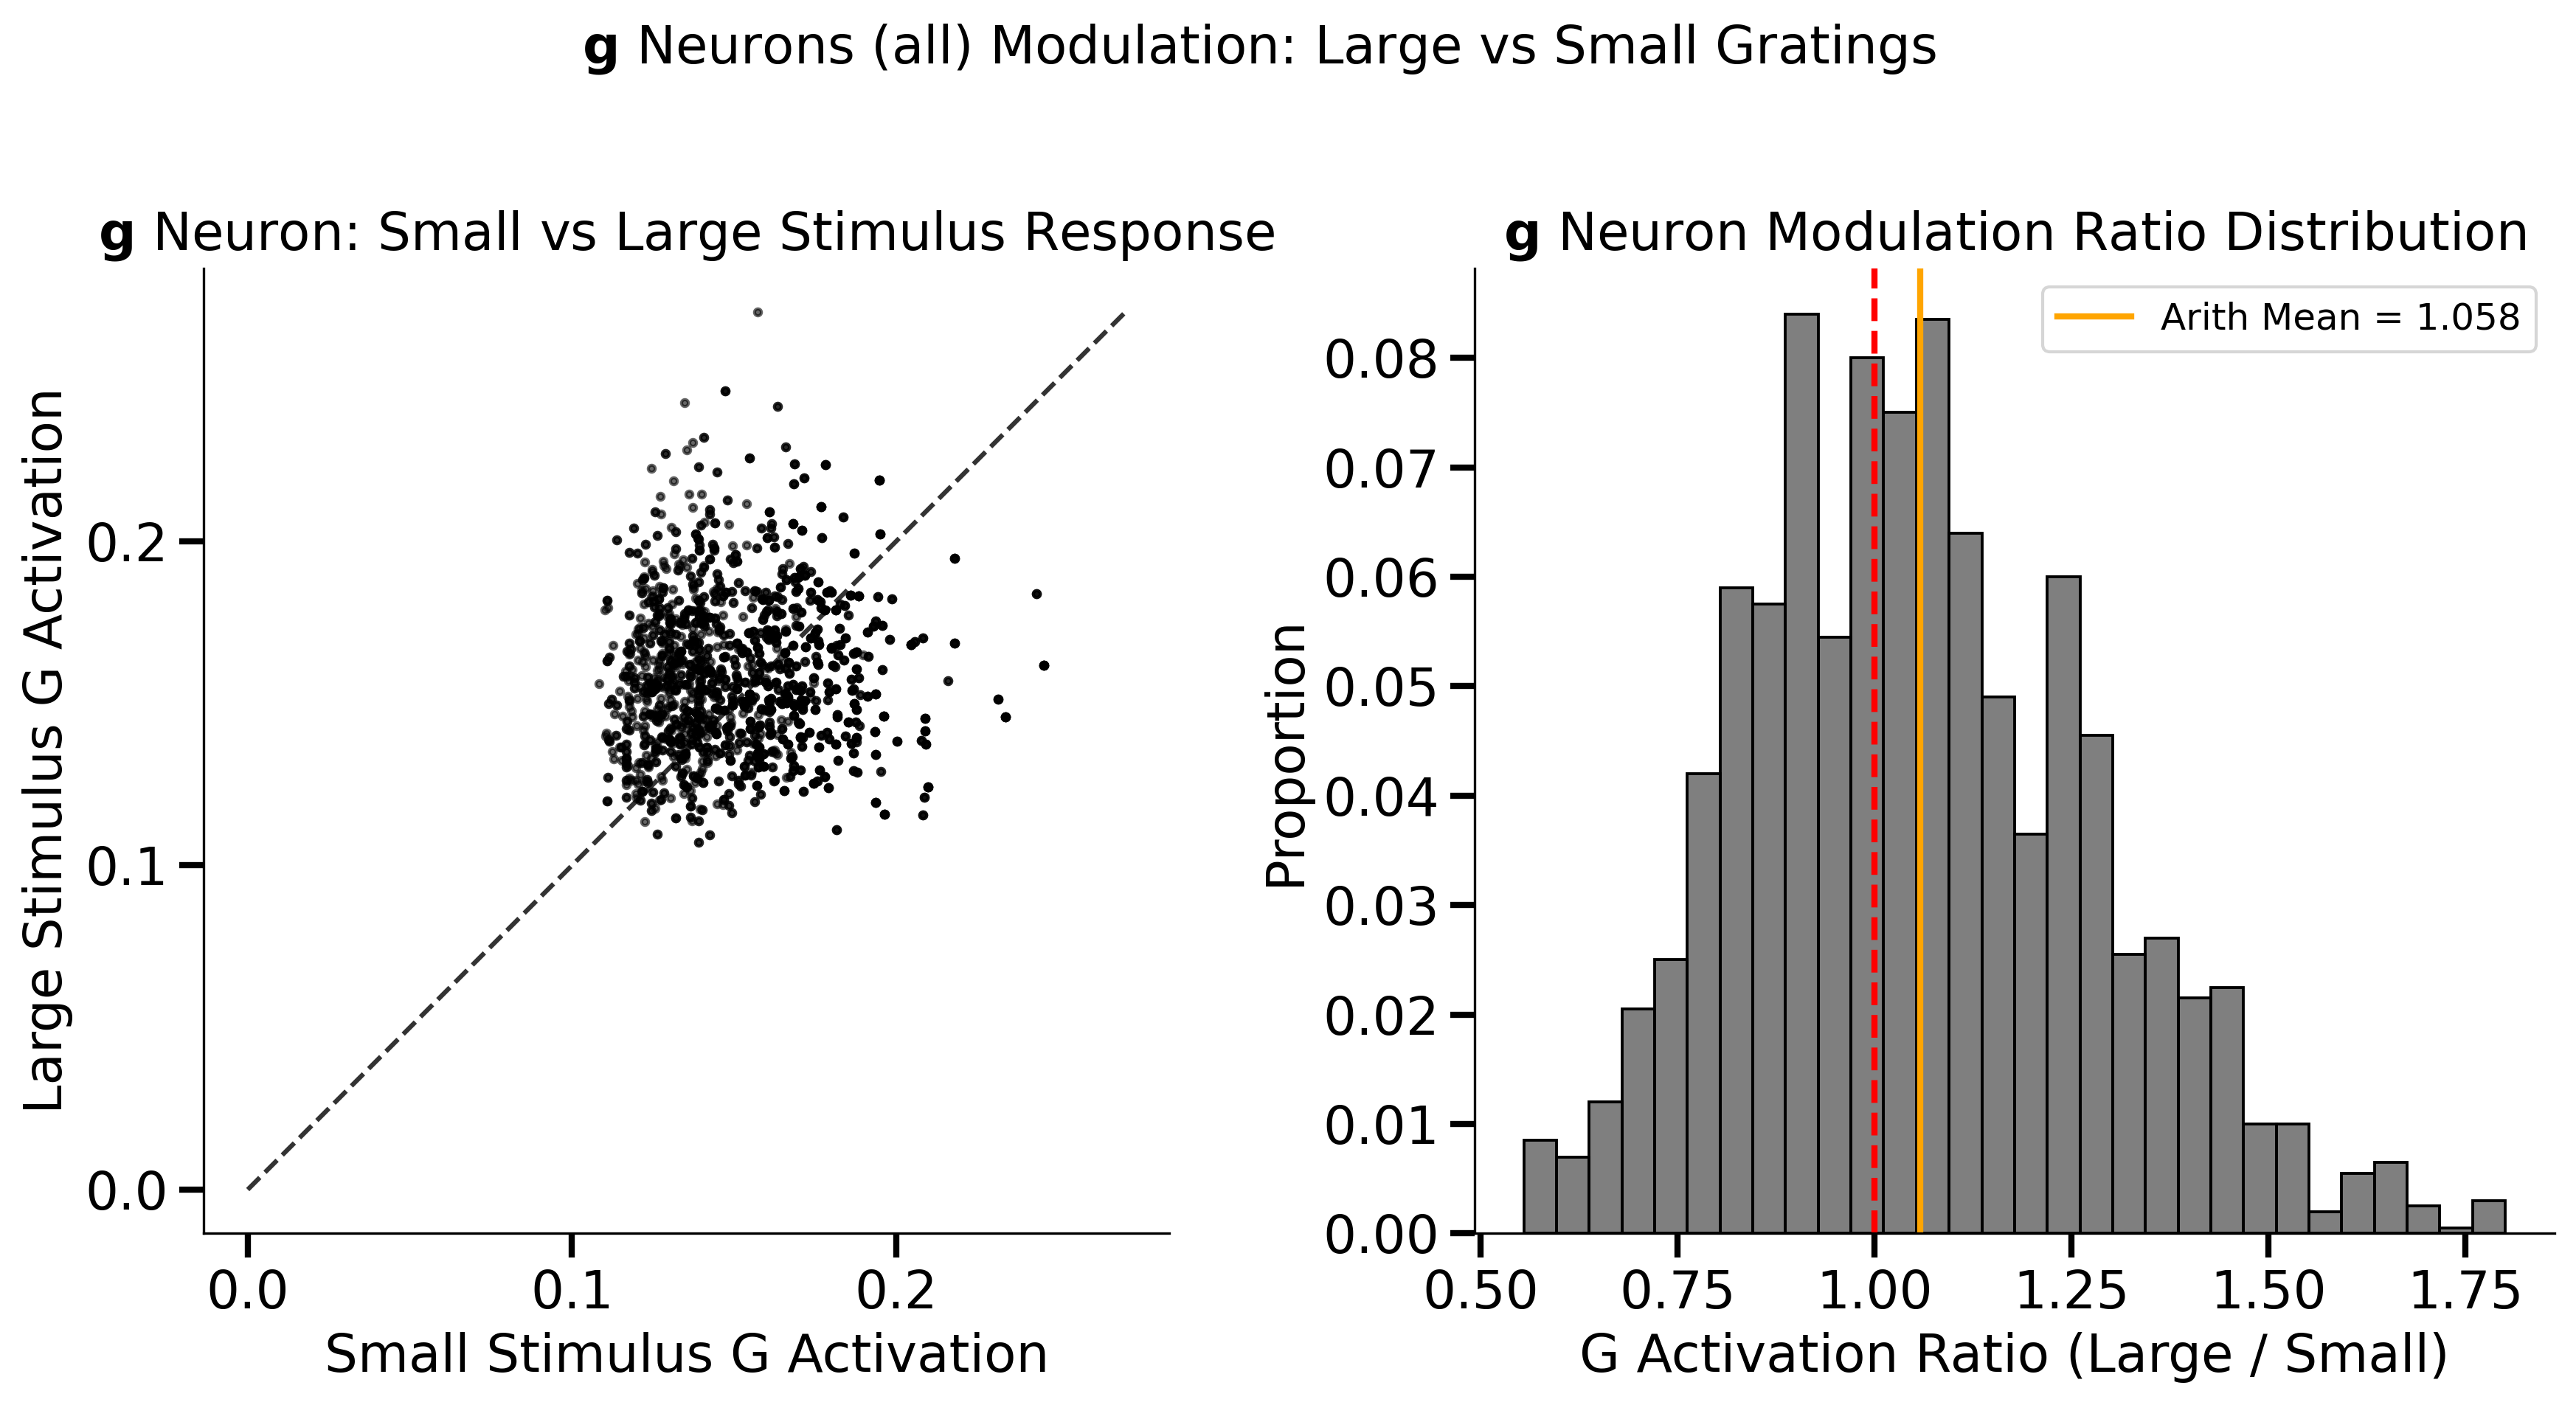

In [19]:
# Comprehensive Visualization: $\\mathbf{g}$ Neuron Inhibitory Response Analysis
# Style parameters
scatter_alpha = 0.6
yx_alpha = 0.8
yx_color = "black"
grid_alpha = 0.3
scatter_size = 5
scatter_color = "black"
xlabel_size = 17
ylabel_size = 17
title_size = 17
tick_label_size = 17
tick_length = 8
tick_width = 2

bins = 30
bar_alpha = 0.5
bar_color = 'black'
edge_color = 'black'
no_diffline_color = 'red'
no_diffline_width = 2

mean_line_color = 'orange'
mean_line_width = 2

legend_size = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# 1. G Neuron Responses: Small vs Big
axes[0].scatter(top_stimuli_df['small_g_mean'], top_stimuli_df['big_g_mean'], 
                alpha=scatter_alpha, s=scatter_size, color=scatter_color)
axes[0].plot([0.0, top_stimuli_df['big_g_mean'].max()], 
             [0.0, top_stimuli_df['big_g_mean'].max()], '--', alpha=yx_alpha, color=yx_color)
axes[0].set_xlabel('Small Stimulus G Activation', fontsize=xlabel_size)
axes[0].set_ylabel('Large Stimulus G Activation', fontsize=ylabel_size)
axes[0].set_title('$\\mathbf{g}$ Neuron: Small vs Large Stimulus Response', fontsize=title_size)
axes[0].set_xticks(np.arange(0.0, top_stimuli_df['big_g_mean'].max() + 0.01, 0.1))
axes[0].set_yticks(np.arange(0.0, top_stimuli_df['big_g_mean'].max() + 0.01, 0.1))
# axes[0].legend(prop={'size': legend_size})
axes[0].set_aspect('equal', adjustable='box')

# 2. $\\mathbf{g}$ Neuron Activation Ratio Distribution
sns.histplot(top_stimuli_df['g_activation_ratio'], bins=bins, alpha=bar_alpha, 
             edgecolor=edge_color, color=bar_color, ax=axes[1], stat='proportion')
axes[1].axvline(1, color=no_diffline_color, linestyle='--', linewidth=no_diffline_width)
mean_g_mr = top_stimuli_df['g_activation_ratio'].mean()
axes[1].axvline(mean_g_mr, color=mean_line_color, linestyle='-', linewidth=mean_line_width,
                label=f'Arith Mean = {mean_g_mr:.3f}')
axes[1].set_xlabel('G Activation Ratio (Large / Small)', fontsize=xlabel_size)
axes[1].set_ylabel('Proportion', fontsize=ylabel_size)
axes[1].set_title('$\\mathbf{g}$ Neuron Modulation Ratio Distribution', fontsize=title_size)
axes[1].legend(prop={'size': legend_size})

# Apply consistent styling to both axes
for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='minor', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='both', length=tick_length, width=tick_width)
    sns.despine(ax=ax)

fig.suptitle('$\\mathbf{g}$ Neurons (all) Modulation: Large vs Small Gratings', fontsize=title_size, y=1.05)
plt.tight_layout()
plt.show()
fig.savefig('g_neuron_all_large_vs_small_gratings.pdf', dpi=300, bbox_inches='tight')

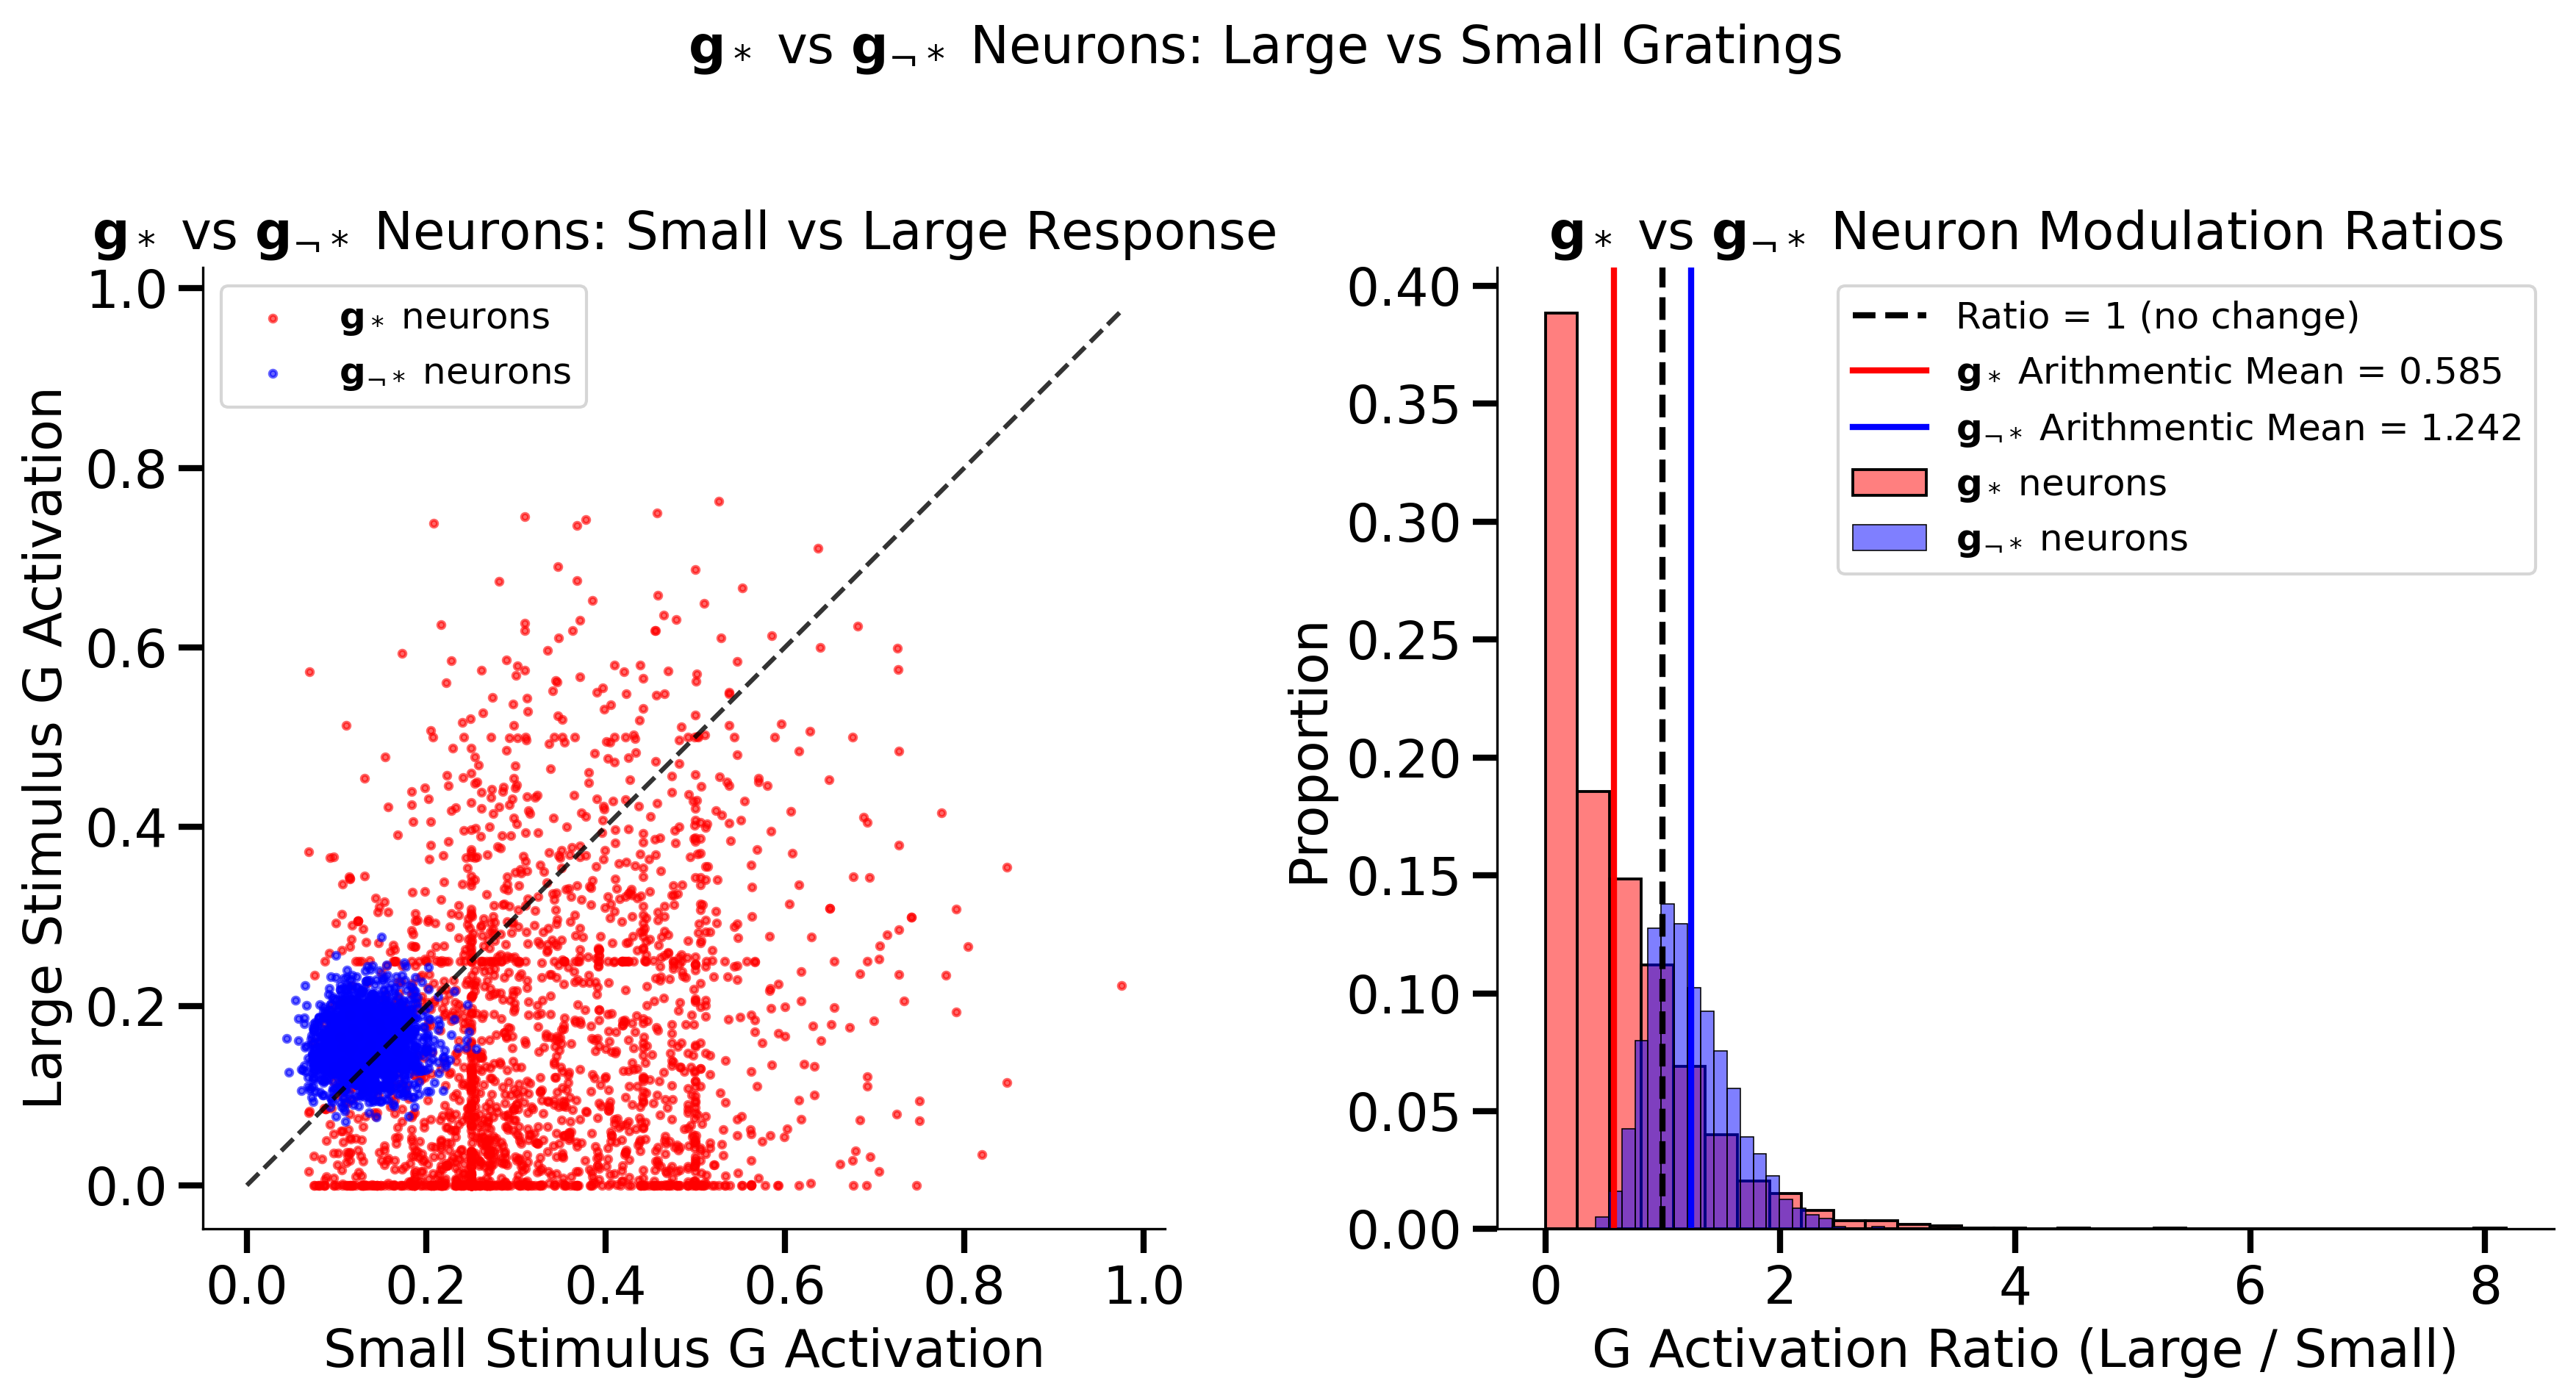

In [17]:
# $\\mathbf{g}_*$ vs $\\mathbf{g}_{\neg *}$ Neurons Comparison Visualization
# Extract "$\\mathbf{g}_{\neg *}$ neuron" responses for comparison
# Style parameters
scatter_alpha = 0.6
yx_alpha = 0.8
yx_color = "black"
scatter_size = 5
g_star_color = "red"
g_others_color = "blue"
xlabel_size = 17
ylabel_size = 17
title_size = 17
tick_label_size = 17
tick_length = 8
tick_width = 2

bins = 30
bar_alpha = 0.5
edge_color = 'black'
no_diffline_color = 'black'
no_diffline_width = 2
mean_line_width = 2
legend_size = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# 1. $\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neuron Responses: Small vs Large
axes[0].scatter(top_stimuli_df['small_g_star'], top_stimuli_df['big_g_star'], 
                alpha=scatter_alpha, s=scatter_size, color=g_star_color, label='$\\mathbf{g}_*$ neurons')
axes[0].scatter(top_stimuli_df['small_g_others'], top_stimuli_df['big_g_others'], 
                alpha=scatter_alpha, s=scatter_size, color=g_others_color, label='$\\mathbf{g}_{\\neg *}$ neurons')
axes[0].plot([0, max(top_stimuli_df['small_g_star'].max(), top_stimuli_df['small_g_others'].max())], 
             [0, max(top_stimuli_df['small_g_star'].max(), top_stimuli_df['small_g_others'].max())], 
             '--', alpha=yx_alpha, color=yx_color)
axes[0].set_xlabel('Small Stimulus G Activation', fontsize=xlabel_size)
axes[0].set_ylabel('Large Stimulus G Activation', fontsize=ylabel_size)
axes[0].set_title(r'$\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neurons: Small vs Large Response', fontsize=title_size)
axes[0].legend(prop={'size': legend_size}, loc='upper left')
axes[0].set_aspect('equal', adjustable='box')

# 2. $\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neuron Activation Ratio Distribution
sns.histplot(top_stimuli_df['g_star_activation_ratio'], bins=bins, alpha=bar_alpha, 
             edgecolor=edge_color, color=g_star_color, ax=axes[1], stat='proportion', label='$\\mathbf{g}_*$ neurons')
sns.histplot(top_stimuli_df['g_others_activation_ratio'], bins=bins, alpha=bar_alpha, 
             edgecolor=edge_color, color=g_others_color, ax=axes[1], stat='proportion', label='$\\mathbf{g}_{\\neg *}$ neurons')

axes[1].axvline(1, color=no_diffline_color, linestyle='--', linewidth=no_diffline_width, label='Ratio = 1 (no change)')

# Add arithmetic means
arithmetic_mean_g_star_mr = top_stimuli_df['g_star_activation_ratio'].mean()
axes[1].axvline(arithmetic_mean_g_star_mr, color=g_star_color, linestyle='-', linewidth=mean_line_width,
                label=f'$\\mathbf{{g}}_*$ Arithmentic Mean = {arithmetic_mean_g_star_mr:.3f}')

arithmetic_mean_g_others_mr = top_stimuli_df['g_others_activation_ratio'].mean()
axes[1].axvline(arithmetic_mean_g_others_mr, color=g_others_color, linestyle='-', linewidth=mean_line_width,
                label=f'$\\mathbf{{g}}_{{\\neg *}}$ Arithmentic Mean = {arithmetic_mean_g_others_mr:.3f}')

axes[1].set_xlabel('G Activation Ratio (Large / Small)', fontsize=xlabel_size)
axes[1].set_ylabel('Proportion', fontsize=ylabel_size)
axes[1].set_title(r'$\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neuron Modulation Ratios', fontsize=title_size)
axes[1].legend(prop={'size': legend_size})

# Apply consistent styling to both axes
for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='minor', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='both', length=tick_length, width=tick_width)
    sns.despine(ax=ax)

fig.suptitle(r'$\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neurons: Large vs Small Gratings', fontsize=title_size, y=1.05)
plt.tight_layout()
plt.show()
fig.savefig('g_star_vs_other_g_neurons_gratings.pdf', dpi=300, bbox_inches='tight')